# Credit Risk Analysis - Deeper EDA

This notebook continues the exploratory data analysis with:
- Binary target variable creation
- Temporal analysis
- Feature analysis (numerical & categorical)
- Default rate segmentation
- Correlation analysis

## 1. Setup and Load Data

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 100)

# Load the sample
df = pd.read_csv('../data/sample_100k_stratified.csv', low_memory=False)
print(f"Data loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Data loaded: 100,000 rows x 152 columns


## 2. Create Binary Target Variable

Define:
- **Default (1)**: Charged Off, Default, Late (31-120 days), Late (16-30 days)
- **Non-Default (0)**: Fully Paid, Current

In [14]:
# Define default categories
default_statuses = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)']

# Create binary target
df['is_default'] = df['loan_status'].apply(lambda x: 1 if x in default_statuses else 0)

# Check distribution
print("Binary Target Distribution:")
print(df['is_default'].value_counts())
print("\nPercentages:")
print(df['is_default'].value_counts(normalize=True) * 100)
print(f"\n✅ Default Rate: {df['is_default'].mean()*100:.2f}%")

Binary Target Distribution:
is_default
0    87158
1    12842
Name: count, dtype: int64

Percentages:
is_default
0    87.158
1    12.842
Name: proportion, dtype: float64

✅ Default Rate: 12.84%


## 3. Temporal Analysis

### Note on Temporal Imbalance

**Concern:** The sample shows significant imbalance across years:
- Pre-2015 (2007-2014): ~20% of data (~20k loans)
- Post-2015 (2015-2018): ~80% of data (~80k loans)

**Question:** Should we use all years or only 2015-2018 for fairness?

**Decision:** I decided to include all years (2007-2018) because:
1. This is classification, not time series forecasting
2. Economic diversity (financial crisis + recovery + boom) makes the model more robust
3. More data generally improves ML models
4. We can assess if lending practices changed significantly and adjust if needed

**Action:** Analyze default rates over time to check for significant shifts in patterns.

In [27]:

print("Default Rate Analysis Across Time Periods:")
print("="*60)


default_rate_by_year = df.groupby('issue_year')['is_default'].mean() * 100
print("Default Rate by Year:")
print(default_rate_by_year)

df['period'] = df['issue_year'].apply(lambda x: 'Pre-2015 (2007-2014)' if x < 2015 else 'Post-2015 (2015-2018)')

period_comparison = df.groupby('period')['is_default'].agg(['mean', 'count'])
period_comparison['mean'] = period_comparison['mean'] * 100

print("" + "="*60)
print("PERIOD COMPARISON:")
print("="*60)
print(period_comparison)

# Statistical test (Chi-square)
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['period'], df['is_default'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Test for Independence:")
print(f"  Chi-square statistic: {chi2:.4f}")
print(f"  P-value: {p_value:.6f}")
print(f"  Degrees of freedom: {dof}")



Default Rate Analysis Across Time Periods:
Default Rate by Year:
issue_year
2007.0     3.571429
2008.0     2.941176
2009.0    11.682243
2010.0    10.374150
2011.0    16.261880
2012.0    17.062818
2013.0    14.912281
2014.0    17.410409
2015.0    18.363437
2016.0    16.293496
2017.0    10.731150
2018.0     3.533946
Name: is_default, dtype: float64
PERIOD COMPARISON:
                            mean  count
period                                 
Post-2015 (2015-2018)  11.975913  79710
Pre-2015 (2007-2014)   16.244455  20290
Chi-Square Test for Independence:
  Chi-square statistic: 262.8965
  P-value: 0.000000
  Degrees of freedom: 1


There is a significant statistical difference between pre-2015 and post-2015 periods. I will be considering methods to handle this in future updates.

In [ ]:
df['issue_date'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
df['issue_year'] = df['issue_date'].dt.year

print(f"Loan Issue Date Range: {df['issue_date'].min()} to {df['issue_date'].max()}")
print(f"\nLoans by Year:\n{df['issue_year'].value_counts().sort_index()}")

Loan Issue Date Range: 2007-06-01 00:00:00 to 2018-12-01 00:00:00

Loans by Year:
issue_year
2007.0       28
2008.0      102
2009.0      214
2010.0      588
2011.0      947
2012.0     2356
2013.0     5814
2014.0    10241
2015.0    18270
2016.0    20634
2017.0    19271
2018.0    21534
Name: count, dtype: int64


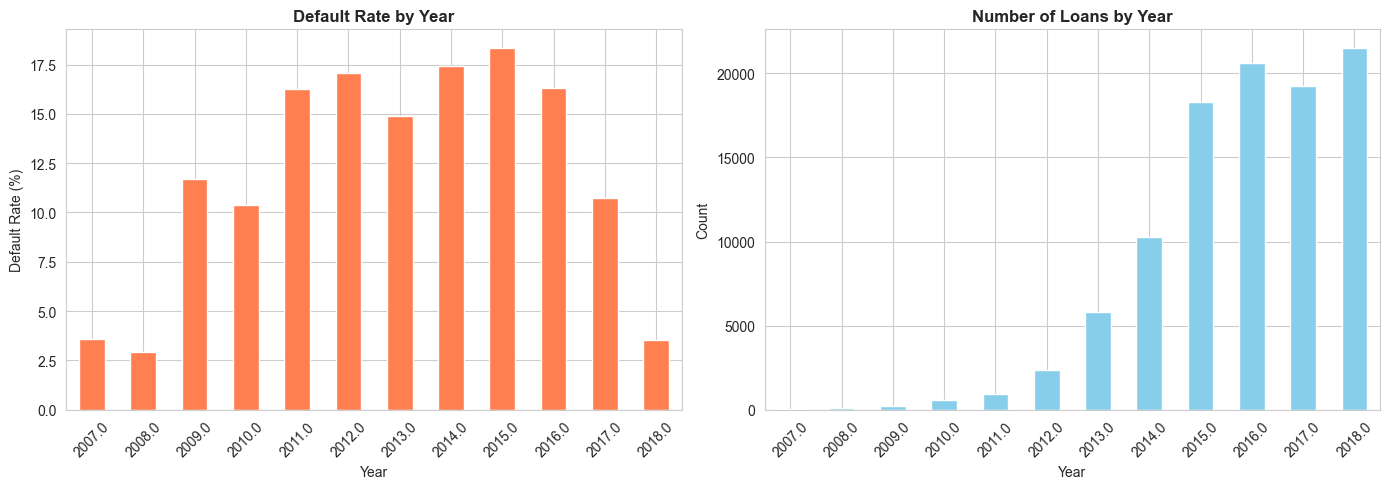


Default Rate by Year:
                 mean  count
issue_year                  
2007.0       3.571429     28
2008.0       2.941176    102
2009.0      11.682243    214
2010.0      10.374150    588
2011.0      16.261880    947
2012.0      17.062818   2356
2013.0      14.912281   5814
2014.0      17.410409  10241
2015.0      18.363437  18270
2016.0      16.293496  20634
2017.0      10.731150  19271
2018.0       3.533946  21534


In [16]:
# Default rate by year
default_by_year = df.groupby('issue_year')['is_default'].agg(['mean', 'count'])
default_by_year['mean'] = default_by_year['mean'] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

default_by_year['mean'].plot(kind='bar', color='coral', ax=ax1)
ax1.set_title('Default Rate by Year', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Default Rate (%)')
ax1.tick_params(axis='x', rotation=45)

default_by_year['count'].plot(kind='bar', color='skyblue', ax=ax2)
ax2.set_title('Number of Loans by Year', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nDefault Rate by Year:")
print(default_by_year)

## 4. Loan Grade Analysis

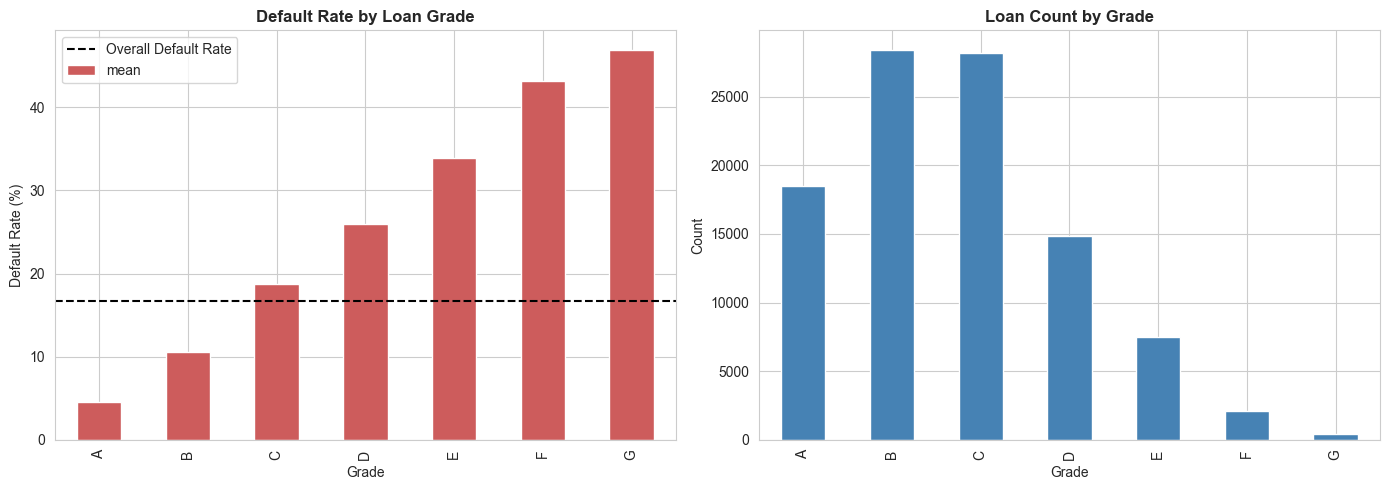


Default Rate by Grade:
            mean  count
grade                  
A       4.617129  18518
B      10.630656  28399
C      18.740912  28195
D      26.001613  14876
E      33.835489   7501
F      43.102625   2095
G      46.875000    416


In [ ]:
default_by_grade = df.groupby('grade')['is_default'].agg(['mean', 'count'])
default_by_grade['mean'] = default_by_grade['mean'] * 100
default_by_grade = default_by_grade.sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

default_by_grade['mean'].plot(kind='bar', color='indianred', ax=ax1)
ax1.set_title('Default Rate by Loan Grade', fontweight='bold')
ax1.set_xlabel('Grade')
ax1.set_ylabel('Default Rate (%)')
ax1.axhline(df['is_default'].mean()*100, color='black', linestyle='--', label='Overall Default Rate')
ax1.legend()

df['grade'].value_counts().sort_index().plot(kind='bar', color='steelblue', ax=ax2)
ax2.set_title('Loan Count by Grade', fontweight='bold')
ax2.set_xlabel('Grade')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\nDefault Rate by Grade:")
print(default_by_grade)

## 5. Numerical Features Analysis

In [6]:
# Key numerical features
numerical_features = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'revol_util']

print("Numerical Features: Defaults vs Non-Defaults\n")
for feature in numerical_features:
    if feature in df.columns:
        print(f"\n{feature}:")
        comparison = df.groupby('is_default')[feature].describe()[['mean', '50%', 'std']].round(2)
        comparison.index = ['Non-Default', 'Default']
        print(comparison)

Numerical Features: Defaults vs Non-Defaults


loan_amnt:
                 mean      50%      std
Non-Default  15283.84  13800.0  8904.41
Default      15943.23  15000.0  8550.73

int_rate:
              mean    50%   std
Non-Default  12.08  11.53  4.27
Default      15.01  14.65  4.38

annual_inc:
                 mean      50%       std
Non-Default  78167.03  65000.0  67485.77
Default      70443.23  60000.0  55909.61

dti:
              mean    50%    std
Non-Default  18.88  18.02  12.04
Default      20.87  20.54   9.45

fico_range_low:
               mean    50%    std
Non-Default  697.79  690.0  32.75
Default      686.23  680.0  24.91

revol_util:
              mean   50%    std
Non-Default  51.62  51.6  24.46
Default      55.08  55.5  23.51


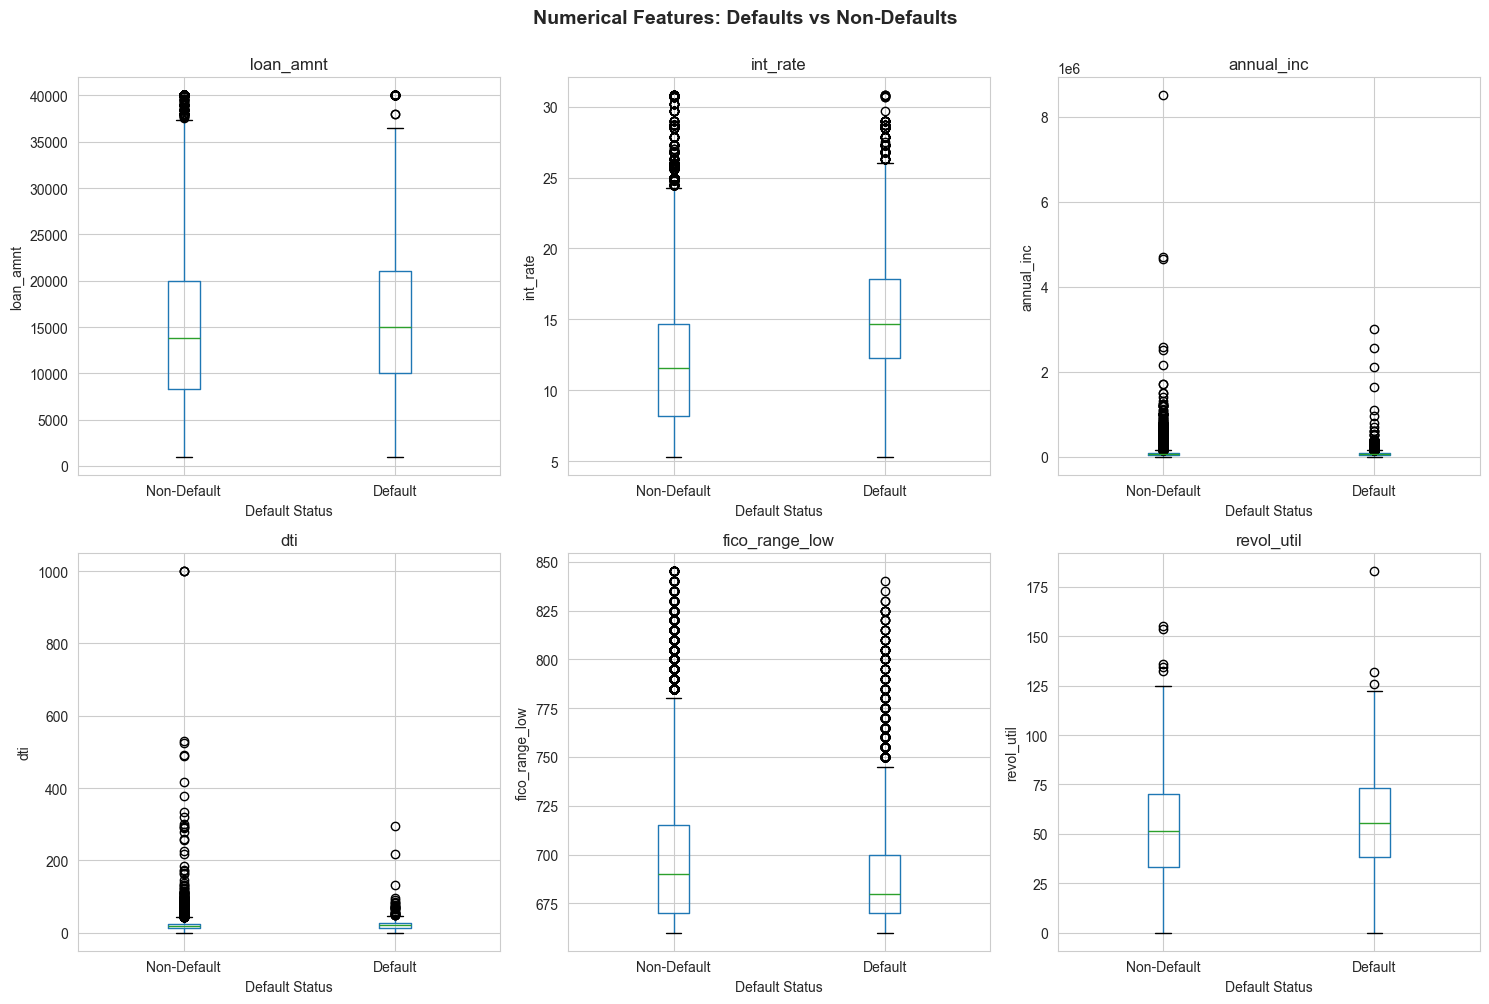

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low', 'revol_util']):
    if feature in df.columns and idx < 6:
        df.boxplot(column=feature, by='is_default', ax=axes[idx])
        axes[idx].set_title(f'{feature}')
        axes[idx].set_xlabel('Default Status')
        axes[idx].set_ylabel(feature)
        axes[idx].set_xticklabels(['Non-Default', 'Default'])
        axes[idx].get_figure().suptitle('')

plt.suptitle('Numerical Features: Defaults vs Non-Defaults', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 6. Categorical Features

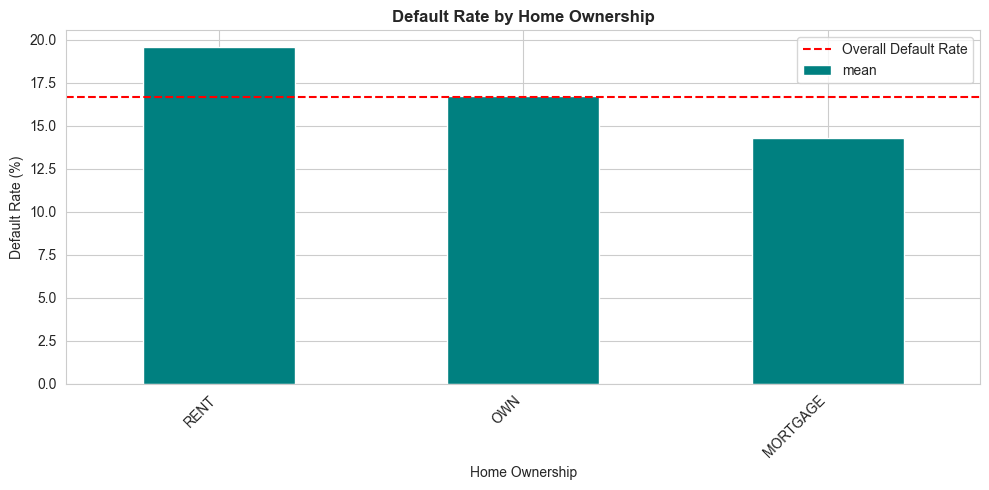

Default Rate by Home Ownership:
                     mean  count
home_ownership                  
RENT            19.557288  39755
OWN             16.711932  11046
MORTGAGE        14.311266  49199


In [ ]:
home_default = df.groupby('home_ownership')['is_default'].agg(['mean', 'count'])
home_default['mean'] = home_default['mean'] * 100
home_default = home_default.sort_values('mean', ascending=False)

plt.figure(figsize=(10, 5))
home_default['mean'].plot(kind='bar', color='teal')
plt.title('Default Rate by Home Ownership', fontweight='bold')
plt.xlabel('Home Ownership')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.axhline(df['is_default'].mean()*100, color='red', linestyle='--', label='Overall Default Rate')
plt.legend()
plt.tight_layout()
plt.show()

print("Default Rate by Home Ownership:")
print(home_default)

### Loan Purpose

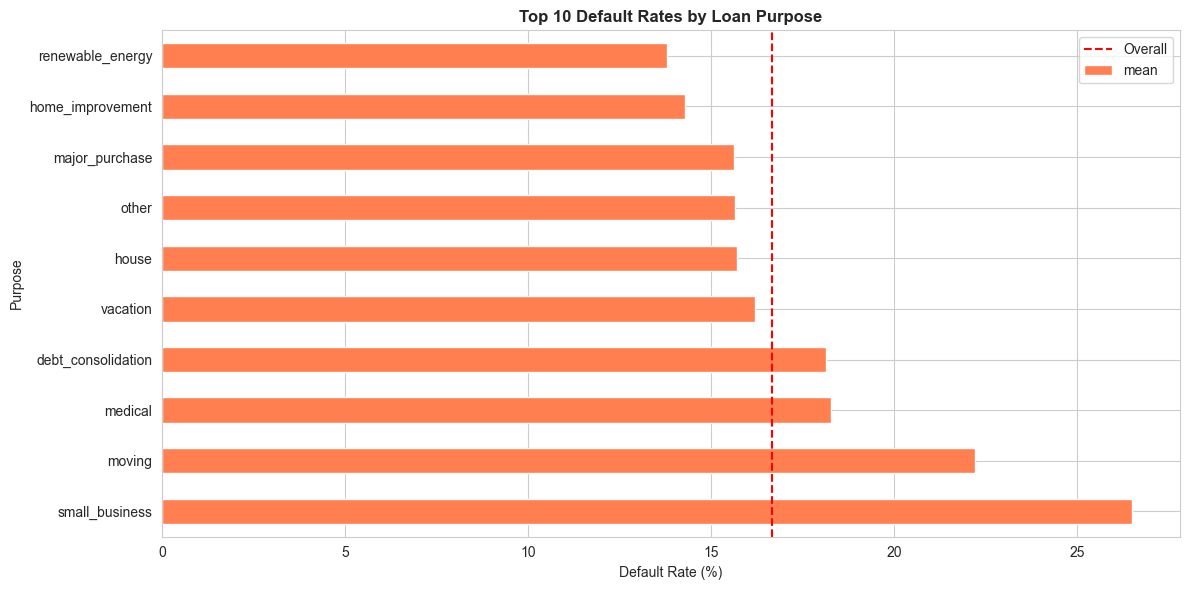


Top 10 Default Rates by Purpose:
                         mean  count
purpose                             
small_business      26.484561    842
moving              22.204214    617
medical             18.276515   1056
debt_consolidation  18.131764  58301
vacation            16.192171    562
house               15.699659    586
other               15.663117   5165
major_purchase      15.613577   1915
home_improvement    14.292675   6157
renewable_energy    13.793103     58


In [ ]:
purpose_default = df.groupby('purpose')['is_default'].agg(['mean', 'count'])
purpose_default['mean'] = purpose_default['mean'] * 100
purpose_default = purpose_default.sort_values('mean', ascending=False).head(10)

plt.figure(figsize=(12, 6))
purpose_default['mean'].plot(kind='barh', color='coral')
plt.title('Top 10 Default Rates by Loan Purpose', fontweight='bold')
plt.xlabel('Default Rate (%)')
plt.ylabel('Purpose')
plt.axvline(df['is_default'].mean()*100, color='red', linestyle='--', label='Overall')
plt.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 Default Rates by Purpose:")
print(purpose_default)

## 7. Correlation Analysis

In [ ]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
correlations = df[numerical_cols].corr()['is_default'].sort_values(ascending=False)
correlations = correlations.drop('is_default')

print("Top 15 Features Positively Correlated with Default:")
print(correlations.head(15))
print("\nTop 15 Features Negatively Correlated with Default:")
print(correlations.tail(15))

Top 15 Features Positively Correlated with Default:
recoveries                                    0.502541
collection_recovery_fee                       0.498333
hardship_dpd                                  0.253995
int_rate                                      0.246608
acc_open_past_24mths                          0.123727
total_rec_late_fee                            0.115902
num_tl_op_past_12m                            0.112430
inq_last_6mths                                0.091319
sec_app_inq_last_6mths                        0.076162
sec_app_collections_12_mths_ex_med            0.074222
open_rv_24m                                   0.072135
open_acc_6m                                   0.069162
percent_bc_gt_75                              0.068527
orig_projected_additional_accrued_interest    0.067324
inq_last_12m                                  0.065711
Name: is_default, dtype: float64

Top 15 Features Negatively Correlated with Default:
sec_app_fico_range_high   -0.164061
s

### Visualizing top correlations

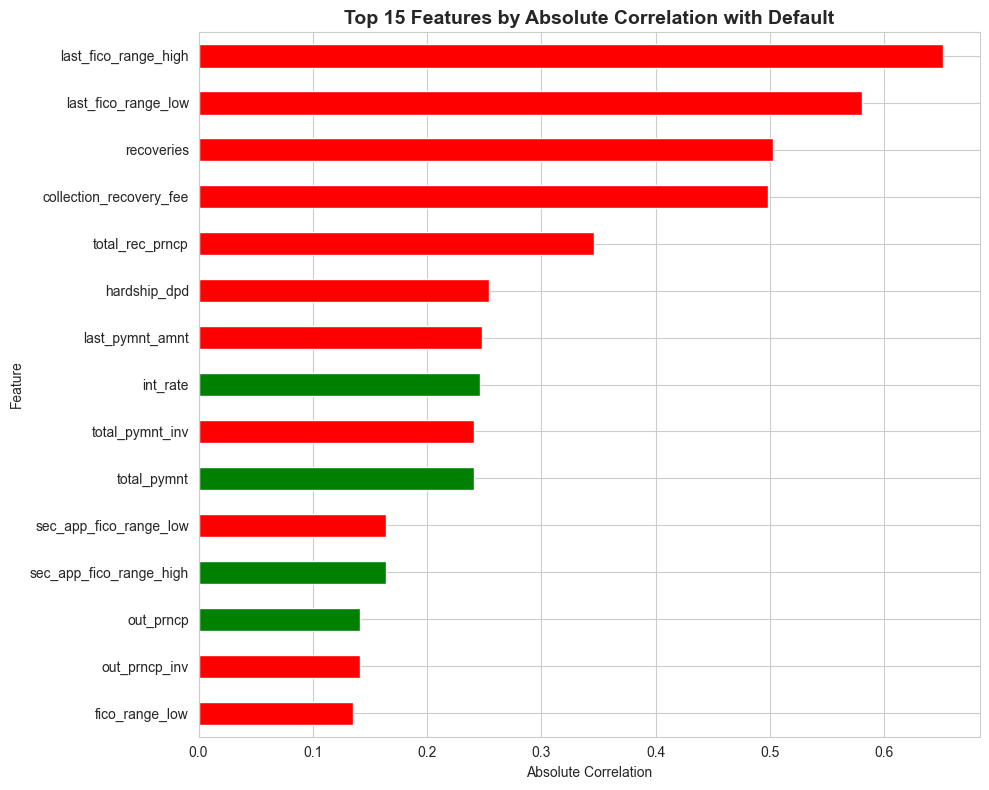

In [ ]:
top_features = correlations.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 8))
colors = ['red' if correlations[feat] < 0 else 'green' for feat in top_features.index]
top_features.sort_values().plot(kind='barh', color=colors)
plt.title('Top 15 Features by Absolute Correlation with Default', fontweight='bold', fontsize=14)
plt.xlabel('Absolute Correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 8. Key Insights Summary

In [17]:
print("="*70)
print("EXPLORATORY DATA ANALYSIS - KEY FINDINGS")
print("="*70)

print(f"\n1. DATASET OVERVIEW:")
print(f"   - Total loans in sample: {len(df):,}")
print(f"   - Date range: {df['issue_date'].min().strftime('%Y-%m')} to {df['issue_date'].max().strftime('%Y-%m')}")
print(f"   - Number of features: {df.shape[1]}")

print(f"\n2. DEFAULT RATE:")
print(f"   - Overall default rate: {df['is_default'].mean()*100:.2f}%")
print(f"   - Defaults: {df['is_default'].sum():,}")
print(f"   - Non-defaults: {(len(df) - df['is_default'].sum()):,}")

print(f"\n3. LOAN GRADES:")
print(f"   - Most common grade: {df['grade'].mode()[0]}")
print(f"   - Highest default rate: Grade {default_by_grade['mean'].idxmax()} ({default_by_grade['mean'].max():.2f}%)")
print(f"   - Lowest default rate: Grade {default_by_grade['mean'].idxmin()} ({default_by_grade['mean'].min():.2f}%)")

print(f"\n4. NUMERICAL FEATURES (Median values):")
print(f"   - Median loan amount: ${df['loan_amnt'].median():,.0f}")
print(f"   - Median interest rate: {df['int_rate'].median():.2f}%")
if 'annual_inc' in df.columns:
    print(f"   - Median annual income: ${df['annual_inc'].median():,.0f}")
if 'fico_range_low' in df.columns:
    print(f"   - Median FICO score: {df['fico_range_low'].median():.0f}")

print(f"\n5. TOP RISK FACTORS (Positive correlation with default):")
for i, (feature, corr) in enumerate(correlations.head(5).items(), 1):
    print(f"   {i}. {feature}: {corr:.4f}")

print(f"\n6. TOP PROTECTIVE FACTORS (Negative correlation with default):")
for i, (feature, corr) in enumerate(correlations.tail(5).items(), 1):
    print(f"   {i}. {feature}: {corr:.4f}")

print("\n" + "="*70)

EXPLORATORY DATA ANALYSIS - KEY FINDINGS

1. DATASET OVERVIEW:
   - Total loans in sample: 100,000
   - Date range: 2007-06 to 2018-12
   - Number of features: 154

2. DEFAULT RATE:
   - Overall default rate: 12.84%
   - Defaults: 12,842
   - Non-defaults: 87,158

3. LOAN GRADES:
   - Most common grade: B
   - Highest default rate: Grade G (46.88%)
   - Lowest default rate: Grade A (4.62%)

4. NUMERICAL FEATURES (Median values):
   - Median loan amount: $12,800
   - Median interest rate: 12.62%
   - Median annual income: $65,000
   - Median FICO score: 690

5. TOP RISK FACTORS (Positive correlation with default):
   1. recoveries: 0.5025
   2. collection_recovery_fee: 0.4983
   3. hardship_dpd: 0.2540
   4. int_rate: 0.2466
   5. acc_open_past_24mths: 0.1237

6. TOP PROTECTIVE FACTORS (Negative correlation with default):
   1. deferral_term: nan
   2. hardship_length: nan
   3. settlement_amount: nan
   4. settlement_percentage: nan
   5. settlement_term: nan

